For this project, I am using run7722all_metafix.root that was produced by Arran using his custom Data processor that includes the muon hits (muon_paddle_hits) and the positions of each paddle in the meta tree.<br>

The data contains the data processed for the water PMTs also to link the muon hits with the PMT pulses.<br>
The print out shows that the output tree has 353719 events. The useful variables for this analysis are<br>
- muon_paddle_hits: 1s and 0s whether or not the paddle is hit out of the 134 total.
- digitNHits or digitNhitsCleaned: This is tell us how much energy is deposited in the water tank.
- digitCharge: Same as above but more direct correlation to energy.
- muon_paddle_x,y,z seems to be 164x134 shape. The 134 is for the number of paddles, 164 is actually from the number of root/hdf5 files that were combined together.


In [ ]:
# This block install some 3D plotting capability to your python install. 
# Uncomment and run once to install ipymp or plotly
#%pip install ipympl
#%pip install plotly

In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

meta = ROOT.RDataFrame("meta", "../Data/run7722all_metafix.root")
# Get the xyz position, but we just need the 1st entry (hdf5 file).
x_pos = meta.AsNumpy(columns=["muon_paddle_x"])["muon_paddle_x"][0]
y_pos = meta.AsNumpy(columns=["muon_paddle_y"])["muon_paddle_y"][0]
z_pos = meta.AsNumpy(columns=["muon_paddle_z"])["muon_paddle_z"][0]

print(x_pos[0], y_pos[0], z_pos[0])

695.658 1365.306 -398.908


In [6]:
for i in range(len(x_pos)):
    print(x_pos[i], y_pos[i], z_pos[i])

695.658 1365.306 -398.908
681.278 1337.084 699.896
473.512 1457.321 -398.908
-704.85 -549.402 1972.377
239.707 1513.453 -398.908
234.753 1482.169 699.896
-273.05 -549.402 1972.377
-273.05 549.402 1940.704
-239.707 1513.453 -398.908
-234.753 1482.169 699.896
0.0 0.0 0.0
0.0 0.0 0.0
1270.0 549.402 -1839.012
549.402 920.75 2098.311
549.402 1136.65 2098.311
-488.95 -549.402 1972.377
0.0 0.0 0.0
1016.0 549.402 -1839.012
762.0 549.402 -1839.012
508.0 549.402 -1839.012
254.0 549.402 -1839.012
0.0 549.402 -1839.012
239.707 -1513.453 -398.908
0.0 -1532.319 -398.908
-239.707 -1513.453 -398.908
-473.512 -1457.321 -398.908
-695.658 -1365.306 -398.908
-1270.0 549.402 -1839.012
-1016.0 549.402 -1839.012
-762.0 549.402 -1839.012
-508.0 549.402 -1839.012
-254.0 549.402 -1839.012
473.512 -1457.321 -398.908
695.658 -1365.306 -398.908
900.674 -1239.672 -398.908
1083.513 -1083.513 -398.908
1513.453 -239.707 -398.908
1457.321 -473.512 -398.908
1365.306 -695.658 -398.908
1239.672 -900.674 -398.908
-920.75 5

## Run this box to produce muon_pos_hits array

In [2]:
# Code to combine layer#, xyz positions of the paddle and the event by event hits.
# Layer is the row 0, xyz are row 1 to 3, hit data are 4 to NEvents+4
import ROOT
import numpy as np
import matplotlib.pyplot as plt

meta = ROOT.RDataFrame("meta", "../Data/run7722all_metafix.root")
# Get the xyz position, but we just need the 1st entry (hdf5 file).
x_pos = meta.AsNumpy(columns=["muon_paddle_x"])["muon_paddle_x"][0]
y_pos = meta.AsNumpy(columns=["muon_paddle_y"])["muon_paddle_y"][0]
z_pos = meta.AsNumpy(columns=["muon_paddle_z"])["muon_paddle_z"][0]
#print("x_pos shape:", x_pos.shape)
#print("y_pos shape:", y_pos.shape)
#print("z_pos shape:", z_pos.shape)

output = ROOT.RDataFrame("output", "../Data/run7722all_metafix.root")
# Convert from object array of event vectors to 2D array: NEvents x 134
muon_hits = np.stack(
    output.AsNumpy(["muon_paddle_hit"])["muon_paddle_hit"]
)

# Paddle indices to disable
disabled_paddles = np.array([0, 1, 7, 10, 11, 13, 14, 23, 29, 40, 41, 44, 45, 46,
    48, 49, 51, 58, 65, 67, 75, 78, 81, 82, 88, 93, 103,
    106, 107, 108, 110, 112, 114, 128, 130, 132, 133], dtype=int)

# Validate the indices before applying the mask
disabled_paddles = disabled_paddles[
    (disabled_paddles >= 0) &
    (disabled_paddles < muon_hits.shape[1])
]

# Set these paddles to zero for every event
muon_hits[:, disabled_paddles] = 0

print("muon_hits shape:", muon_hits.shape)

# Add the layer number to row 0 of the 4+NEvents X NPaddle Array.
layer = np.zeros_like(z_pos, dtype=int) # defaults to 0
layer[np.isclose(z_pos, 2129.984)] = 1 # TopUpper-x
layer[np.isclose(z_pos, 2098.311)] = 2 # TopUpper+x
layer[np.isclose(z_pos, 1972.377)] = 3 # TopLower-y
layer[np.isclose(z_pos, 1940.704)] = 4 # TopLower+y
layer[np.isclose(z_pos, 699.896)] = 5 # Barrel+z
layer[np.isclose(z_pos, -398.908)] = 6 # Barrel-z
layer[np.isclose(z_pos, -1807.338)] = 7 # Bottom-y
layer[np.isclose(z_pos, -1839.012)] = 8 # Bottom+y

# Add the xyz position to row 1-3 of the 4+NEvents X NPaddle Array.
muon_pos_hits = np.vstack([
    layer,
    x_pos,
    y_pos,
    z_pos,
    muon_hits
])
print(muon_pos_hits[0,:])
#print("muon_hits_with_pos shape:", muon_pos_hits[0])

muon_hits shape: (353719, 134)
[6. 5. 6. 3. 6. 5. 3. 4. 6. 5. 0. 0. 8. 2. 2. 3. 0. 8. 8. 8. 8. 8. 6. 6.
 6. 6. 6. 8. 8. 8. 8. 8. 6. 6. 6. 6. 6. 6. 6. 6. 4. 5. 4. 4. 3. 4. 3. 7.
 1. 1. 4. 4. 7. 7. 7. 7. 7. 5. 5. 5. 5. 5. 7. 7. 7. 7. 7. 5. 5. 5. 5. 5.
 5. 5. 5. 6. 0. 3. 0. 3. 4. 0. 6. 6. 5. 5. 6. 6. 5. 5. 6. 6. 5. 5. 6. 6.
 5. 5. 6. 6. 5. 5. 6. 6. 5. 5. 0. 0. 2. 6. 1. 5. 2. 6. 1. 5. 2. 2. 1. 1.
 2. 2. 1. 1. 2. 2. 1. 1. 3. 6. 4. 5. 0. 0.]


## Let's look for the easiest events first.
The muon passes through TopUpper, TopLower and Bottom. Assuming the muon is travel almost straight, the three paddle should have a path that can be intersected by a straight line.<br>

### Let's filter for the events that has 1 hit on each TopUpper, TopLower and Bottom and no hits on the barrel.


In [2]:
############### Get a list of Events with only 1 TopUp, TopLow and Bottom hit.
# Get the Columns numbers for each layer.
TopUp = np.where((muon_pos_hits[0] == 1) | (muon_pos_hits[0] == 2))[0]
TopLow = np.where((muon_pos_hits[0] == 3) | (muon_pos_hits[0] == 4))[0]
Bottom = np.where((muon_pos_hits[0] == 7) | (muon_pos_hits[0] == 8))[0]
Barrel = np.where((muon_pos_hits[0] == 5) | (muon_pos_hits[0] == 6))[0]

# Count hits only in the selected columns of the layers
TopUpHits = np.count_nonzero(muon_pos_hits[4:, TopUp] == 1, axis=1)
TopLowHits = np.count_nonzero(muon_pos_hits[4:, TopLow] == 1, axis=1)
BottomHits = np.count_nonzero(muon_pos_hits[4:, Bottom] == 1, axis=1)
BarrelHits = np.count_nonzero(muon_pos_hits[4:, Barrel] == 1, axis=1)
event_list = []

for iEvt in range(4,len(muon_pos_hits[4:])):
    if TopUpHits[iEvt] == 1 and TopLowHits[iEvt] == 1 and BottomHits[iEvt] == 1 and BarrelHits[iEvt] == 0:
        event_list.append(iEvt)
       # print(
       #     f"Event {event_number}: "
       #     f"TopUpper = {upper_count} hits, "
       #     f"TopLower = {lower_count} hits"
       #     f"Bottom = {bottom_count} hits"
       #     f"Barrel = {barrel_count} hits"
       #     )
print("len(event_list)=",len(event_list))


len(event_list)= 172


## Then try to fit a straight track through all 3 paddles.

In [3]:
from MuonTrack import *

fit_results = []

for EVENTNUM in event_list:
    result = test_event_fit(
        EVENTNUM,
        muon_pos_hits,
        n_trials=10000,
        seed=314159
    )

    fit_results.append(result)

    status = "SUCCESS" if result["success"] else "FAIL"

    print(
        f"Event {EVENTNUM}: {status}, "
        f"n_hits={result['n_hits']}, "
        f"score={result['score']}, "
        f"reason={result['reason']}"
    )

    print(f"  hit columns: {result['hit_columns']}")

    if result["success"]:
        print(f"  line point: {result['line_point']}")
        print(f"  line dir  : {result['line_dir']}")

    print()

n_success = sum(1 for r in fit_results if r["success"])
n_fail = sum(1 for r in fit_results if not r["success"])

print(f"Total success: {n_success}")
print(f"Total fail:    {n_fail}")
print(f"Total events:  {len(fit_results)}")

Event 863: FAIL, n_hits=3, score=None, reason=no line found that intersects all hit boxes
  hit columns: [50, 66, 118]

Event 1378: FAIL, n_hits=3, score=None, reason=no line found that intersects all hit boxes
  hit columns: [30, 50, 118]

Event 1775: SUCCESS, n_hits=3, score=0.28156377598129334, reason=fit successful
  hit columns: [3, 55, 126]
  line point: [  236.07781548  -569.4932874  -1809.35641716]
  line dir  : [-0.23941518  0.07052392  0.9683526 ]

Event 4870: FAIL, n_hits=3, score=None, reason=no line found that intersects all hit boxes
  hit columns: [21, 42, 127]

Event 5107: FAIL, n_hits=3, score=None, reason=no line found that intersects all hit boxes
  hit columns: [50, 63, 122]

Event 7374: FAIL, n_hits=3, score=None, reason=no line found that intersects all hit boxes
  hit columns: [20, 43, 76, 127]

Event 7512: FAIL, n_hits=3, score=None, reason=no line found that intersects all hit boxes
  hit columns: [43, 52, 76, 127]

Event 11466: FAIL, n_hits=3, score=None, reas

### Most of the events are failing to have a straight line fitting through them.

### Let's analyze the water PMT data where we have these three paddle hits. Not applying the straight cut for now.

### Let's look at the Total Charge in the water PMTs next.


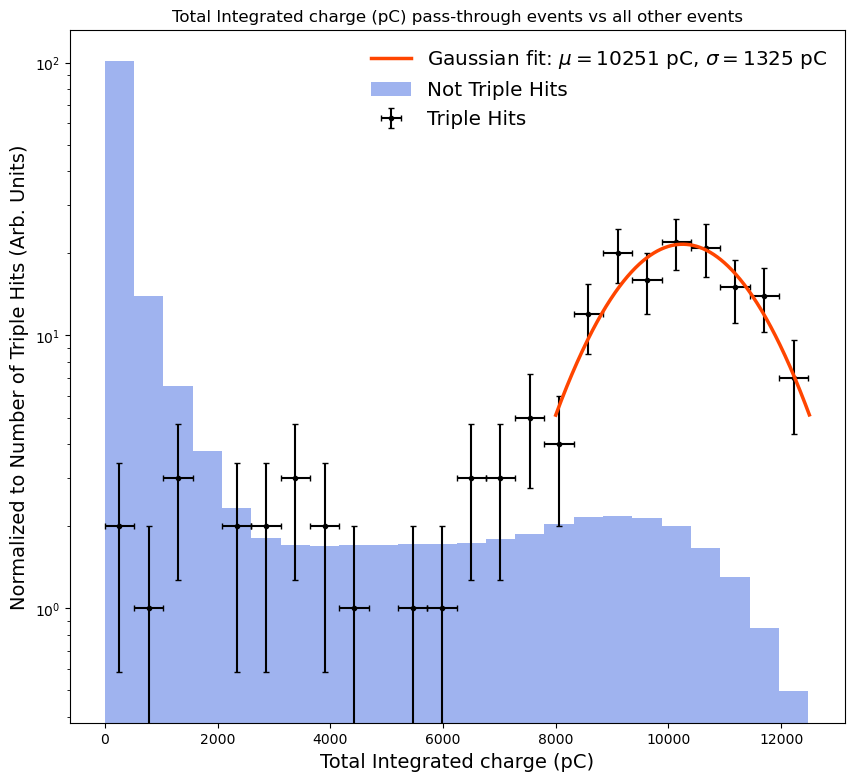

In [5]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from Eos import gaussian, apply_eos_plot_style

apply_eos_plot_style()
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_title("Total Integrated charge (pC) pass-through events vs all other events")
ax.set_xlabel("Total Integrated charge (pC)", fontsize=14)
ax.set_ylabel("Normalized to Number of Triple Hits (Arb. Units)", fontsize=14)
ax.set_yscale("log")

# Read charge array branch
digitCharge = output.AsNumpy(columns=["digitCharge"])["digitCharge"]

# Sum only charges above 0.5 in each event
digitTotalCharge = np.array([np.sum(np.asarray(charges)[np.asarray(charges) > 0.5]) 
    for charges in digitCharge],dtype=float)

n_events = len(digitTotalCharge)

event_list = np.array(event_list, dtype=int)

selected_events = event_list
all_events = np.arange(n_events, dtype=int)
other_events = np.setdiff1d(all_events, selected_events)

selected_charge = digitTotalCharge[selected_events]
other_charge = digitTotalCharge[other_events]

selected_counts, charge_bins = np.histogram(
    selected_charge,
    bins=np.arange(0, 13000, 520)
)

other_counts, _ = np.histogram(
    other_charge,
    bins=charge_bins
)

other_counts = other_counts * np.sum(selected_counts) / np.sum(other_counts)

charge_bin_centers = 0.5 * (
    charge_bins[:-1] + charge_bins[1:]
)


ax.bar(
    charge_bin_centers,
    other_counts,
    width=520,
    color="royalblue",
    alpha=0.5,
    label=f"Not Triple Hits",# ({len(other_events)} events)",
    zorder=1
)

ax.errorbar(
    charge_bin_centers,
    selected_counts,
    yerr=np.sqrt(selected_counts),
    xerr=260,
    color="black",
    marker=".",
    linestyle="",
    capsize=2,
    label=f"Triple Hits", # ({len(selected_events)} events)",
    zorder=3
)

# ------------------------------------------------------------
# Gaussian fit to triple-hit histogram around 10,000 pC
# ------------------------------------------------------------
fit_x_range = (8000.0, 12500.0)

fit_mask = (
    (charge_bin_centers >= fit_x_range[0]) &
    (charge_bin_centers <= fit_x_range[1]) &
    (selected_counts > 0)
)

fit_params = None
fit_cov = None

x_fit_data = charge_bin_centers[fit_mask]
y_fit_data = selected_counts[fit_mask]
yerr_fit_data = np.sqrt(y_fit_data)

p0 = [
    20,                      # amplitude guess
    np.mean(fit_x_range),    # mean guess
    1000.0                   # sigma guess
]

bounds = (
    [0.0, fit_x_range[0], 100.0],
    [np.inf, fit_x_range[1], 5000.0]
)

fit_params, fit_cov = curve_fit(
    gaussian,
    x_fit_data,
    y_fit_data,
    p0=p0,
    sigma=yerr_fit_data,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=10000
)

A_fit, mu_fit, sigma_fit = fit_params

x_fit_curve = np.linspace(fit_x_range[0], fit_x_range[1], 500)
y_fit_curve = gaussian(x_fit_curve, A_fit, mu_fit, sigma_fit)

ax.plot(
    x_fit_curve,
    y_fit_curve,
    color="orangered",
    linewidth=2.5,
    label=(
        "Gaussian fit: "
        #rf"$peak={A_fit:.0f}$, "
        rf"$\mu={mu_fit:.0f}$ pC, "
        rf"$\sigma={sigma_fit:.0f}$ pC"
    ),
    zorder=4
)
ax.legend(framealpha=0)
plt.show()

### Most of the events are failing to have a straight line fitting through them.

### Let's analyze the water PMT data where we have these three paddle hits. Not applying the straight cut for now.

### Let's look at the nHits distribution first.


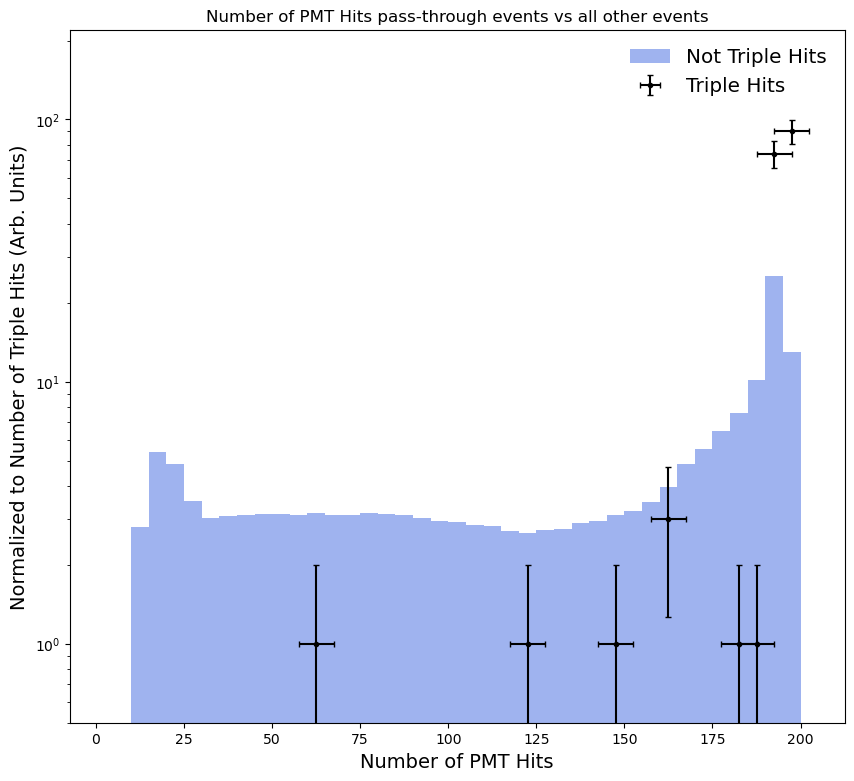

In [6]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from Eos import gaussian, apply_eos_plot_style

apply_eos_plot_style()
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_title("Number of PMT Hits pass-through events vs all other events")
ax.set_xlabel("Number of PMT Hits", fontsize=14)
ax.set_ylabel("Normalized to Number of Triple Hits (Arb. Units)", fontsize=14)
ax.set_yscale("log")

# Read charge array branch
digitNHits = output.AsNumpy(columns=["digitNhits"])["digitNhits"]

n_events = len(digitNHits)

event_list = np.array(event_list, dtype=int)

selected_events = event_list
all_events = np.arange(n_events, dtype=int)
other_events = np.setdiff1d(all_events, selected_events)

selected_nHits = digitNHits[selected_events]
other_nHits = digitNHits[other_events]

selected_counts, nHits_bins = np.histogram(
    selected_nHits,
    bins=np.arange(5, 205, 5)
)

other_counts, _ = np.histogram(
    other_nHits,
    bins=nHits_bins
)

other_counts = other_counts * np.sum(selected_counts) / np.sum(other_counts)

nHits_bin_centers = 0.5 * (
    nHits_bins[:-1] + nHits_bins[1:]
)

ax.bar(
    nHits_bin_centers,
    other_counts,
    width=5,
    color="royalblue",
    alpha=0.5,
    label=f"Not Triple Hits",# ({len(other_events)} events)",
    zorder=1
)

ax.errorbar(
    nHits_bin_centers,
    selected_counts,
    yerr=np.sqrt(selected_counts),
    xerr=5,
    color="black",
    marker=".",
    linestyle="",
    capsize=2,
    label=f"Triple Hits", # ({len(selected_events)} events)",
    zorder=3
)

ax.legend(framealpha=0)
ax.set_ylim(5e-1, 220)
plt.show()

## This draws the 3D positions of all the paddles. 
It will load the 3D plot in qt.

In [8]:
%matplotlib qt
import numpy as np
import matplotlib.pyplot as plt
from MuonTrack import *

fig = plt.figure(figsize=(12, 11))
ax = fig.add_subplot(111, projection="3d")

n_paddles = muon_pos_hits.shape[1]

for col in range(n_paddles):
    layer_value = int(muon_pos_hits[0, col])

    x = muon_pos_hits[1, col]
    y = muon_pos_hits[2, col]
    z = muon_pos_hits[3, col]

    size = box_size_from_layer(layer_value)

    if size is None:
        print(f"Skipping col {col}: unknown layer {layer_value}")
        continue

    if layer_value <= 0:
        continue

    if layer_value in [5, 6]:
        # Barrel paddle:
        # 210 wide tangentially, 10 thick radially, 1300 long in z
        radial_axis, tangential_axis, z_axis = barrel_axes_from_position(x, y)

        draw_oriented_box(
            ax,
            center=(x, y, z),
            axes=(tangential_axis, radial_axis, z_axis),
            size=(210, 10, 1300),
            alpha=0.15,
            facecolor=color_from_layer(layer_value)
        )

    else:
        # Non-barrel paddles remain axis-aligned
        draw_paddle(
            ax,
            center=(x, y, z),
            size=size,
            alpha=0.15,
            facecolor=color_from_layer(layer_value)
        )

    ax.text(x, y, z, str(col), fontsize=7)

ax.set_xlabel("x_pos")
ax.set_ylabel("y_pos")
ax.set_zlabel("z_pos")
ax.set_title("All Muon Paddles")

ax.set_xlim(-1600, 1600)
ax.set_ylim(-1600, 1600)
ax.set_zlim(-2200, 2200)

ax.set_box_aspect((3200, 3200, 4400))

plt.show()

Skipping col 10: unknown layer 0
Skipping col 11: unknown layer 0
Skipping col 16: unknown layer 0
Skipping col 76: unknown layer 0
Skipping col 78: unknown layer 0
Skipping col 81: unknown layer 0
Skipping col 106: unknown layer 0
Skipping col 107: unknown layer 0
Skipping col 132: unknown layer 0
Skipping col 133: unknown layer 0


In [6]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from MuonTrack import *
# Use Qt backend for smoother 3D rotation
# Run this once in a separate notebook cell if needed:
%matplotlib qt

EVENTNUM = 349917

event_hit_row = 4 + EVENTNUM

hit_columns = np.where(muon_pos_hits[event_hit_row] == 1)[0]

print(f"Event {EVENTNUM}")
print("hit columns:", hit_columns)
print("number of hits:", len(hit_columns))

fig = plt.figure(figsize=(10, 11))
ax = fig.add_subplot(111, projection="3d")
hit_boxes = []
hit_centers = []
hit_layers = []
hit_cols = []


for col in hit_columns:
    layer_value = int(muon_pos_hits[0, col])

    x = muon_pos_hits[1, col]
    y = muon_pos_hits[2, col]
    z = muon_pos_hits[3, col]

    print(f"  col {col}: layer={layer_value}, x={x}, y={y}, z={z}")
    
    size = box_size_from_layer(layer_value)
    
    if size is not None:
        draw_paddle(ax, center=(x, y, z), size=size, alpha=0.35, facecolor=color_from_layer(layer_value))

    ax.text(x, y, z, str(col), fontsize=9)

    if size is not None:
        hit_boxes.append({
            "center": np.array([x, y, z], dtype=float),
            "size": np.array(size, dtype=float),
            "bounds": box_bounds(center=(x, y, z), size=size),
            "col": col,
            "layer": layer_value,
        })
    
    hit_centers.append([x, y, z])
    hit_layers.append(layer_value)
    hit_cols.append(col)


ax.set_xlabel("x_pos")
ax.set_ylabel("y_pos")
ax.set_zlabel("z_pos")
ax.set_title(f"Event {EVENTNUM}: Muon Hits with Layer #")

ax.set_xlim(-1600, 1600)
ax.set_ylim(-1600, 1600)
ax.set_zlim(-2200, 2200)

ax.set_box_aspect((3200, 3200, 4400))
hit_centers = np.array(hit_centers, dtype=float)

if len(hit_boxes) >= 2:
    line_point, line_dir, score = fit_line_through_boxes(
        hit_boxes,
        n_trials=10000,
        seed=12345
    )

    if line_point is None:
        print("No line found that intersects all hit boxes.")
        print("Try increasing n_trials.")
    else:
        # Project box centers onto fitted line to choose display length
        centers = np.array([b["center"] for b in hit_boxes], dtype=float)
        t_values = (centers - line_point) @ line_dir

        t_min = t_values.min() - 700
        t_max = t_values.max() + 700

        t_line = np.linspace(t_min, t_max, 100)
        line_xyz = line_point + np.outer(t_line, line_dir)

        ax.plot(
            line_xyz[:, 0],
            line_xyz[:, 1],
            line_xyz[:, 2],
            color="red",
            linewidth=3,
            label="box-aware central line"
        )

        print("\nBox-aware fitted line:")
        print("  point     =", line_point)
        print("  direction =", line_dir)
        print("  score     =", score)

        print("\nDistances from hit box centers to fitted line:")
        for box in hit_boxes:
            dist = point_line_distance(box["center"], line_point, line_dir)
            print(
                f"  col {box['col']}, layer {box['layer']}: "
                f"distance = {dist:.3f}"
            )

        ax.legend()
        ax.text(
            0.5, 0.5,
            "Work In Progress",
            transform=ax.transAxes,
            fontsize=45,
            color="gray",
            alpha=0.25,
            ha="center",
            va="center",
            rotation=-30,
            zorder=1000
        )
else:
    print("Need at least 2 hit boxes to fit a line.")

plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Event 349917
hit columns: [ 12  43  76 123]
number of hits: 4
  col 12: layer=8, x=1270.0, y=549.402, z=-1839.012
  col 43: layer=4, x=488.95, y=549.402, z=1940.704
  col 76: layer=0, x=0.0, y=0.0, z=0.0
  col 123: layer=1, x=-549.402, y=488.95, z=2129.984
No line found that intersects all hit boxes.
Try increasing n_trials.
